In [2]:
import geopandas as gpd
import pandas as pd

basline_blocks = gpd.read_file('./data/niipg/blocks_agg.geojson')
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,is_living,...,count_supermarket,capacity_park,count_park,capacity_train_building,count_train_building,capacity_kindergarten,count_kindergarten,capacity_school,count_school,geometry
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,6.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.09367 59.55207, 30.09375 59.55215..."
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,13.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,650.0,1.0,"POLYGON ((30.09448 59.56164, 30.09448 59.56164..."
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.12546 59.58002, 30.12541 59.57998..."
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,2.0,...,0.0,1200.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.12501 59.56588, 30.12497 59.56582..."
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,..."


# Вычисления **площади участка**

In [3]:
baseline_blocks_test = basline_blocks.copy().to_crs(3857)
basline_blocks["site_area"] = baseline_blocks_test.geometry.area

In [4]:
basline_blocks

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,is_living,...,capacity_park,count_park,capacity_train_building,count_train_building,capacity_kindergarten,count_kindergarten,capacity_school,count_school,geometry,site_area
0,0.690207,0.211718,0.055976,0.000000,0.042093,0.000000,0.0,LandUse.RESIDENTIAL,0.690207,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",8.362778e+05
1,0.970519,0.029484,0.000000,0.000000,0.000000,0.000000,0.0,LandUse.RESIDENTIAL,0.970519,13.0,...,0.0,0.0,0.0,0.0,0.0,0.0,650.0,1.0,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",4.201440e+05
2,0.936589,0.010562,0.052849,0.000000,0.000000,0.000000,0.0,LandUse.RESIDENTIAL,0.936589,15.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",3.029856e+05
3,0.121353,0.819171,0.059489,0.000000,0.000000,0.000000,0.0,LandUse.BUSINESS,0.819171,2.0,...,1200.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",1.245470e+05
4,0.068737,0.931312,0.000000,0.000000,0.000000,0.000000,0.0,LandUse.BUSINESS,0.931312,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",1.195750e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346,0.085212,0.005620,0.000000,0.042102,0.000000,0.877347,0.0,LandUse.SPECIAL,0.877347,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.13472 59.59243, 30.13519 59.59012...",7.517853e+05
347,0.603114,0.000000,0.000000,0.000000,0.000000,0.392772,0.0,LandUse.RESIDENTIAL,0.603114,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.13429 59.59456, 30.13472 59.59243...",8.907641e+05
348,0.921247,0.007951,0.070064,0.000000,0.000000,0.000000,0.0,LandUse.RESIDENTIAL,0.921247,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((30.06949 59.54791, 30.06991 59.54711...",7.114920e+05
349,0.604336,0.000000,0.393593,0.000000,0.000000,0.000000,0.0,LandUse.RESIDENTIAL,0.604336,0.0,...,0.0,0.0,0.0,0.0,220.0,1.0,0.0,0.0,"POLYGON ((30.084 59.5465, 30.08427 59.54673, 3...",5.682778e+05


# Вычисления **связанности**

In [3]:
from blocksnet.analysis.network.accessibility import area_accessibility
matrix = pd.read_pickle('./data/niipg/matrix.pickle')

area_acc_df = area_accessibility(matrix, basline_blocks)
basline_blocks = basline_blocks.join(area_acc_df)
basline_blocks.head()

ValueError: Accessibility matrix columns must be in blocks index

# Вычисления **показателей застройки**

In [4]:
from blocksnet.analysis.indicators import calculate_density_indicators 

blocks_df = calculate_density_indicators(basline_blocks[[
    'site_area',
    'footprint_area',
    'build_floor_area',
    'living_area'
]])
blocks_df.head()

2025-11-25 15:54:57.848 | WARNING  | blocksnet.analysis.indicators.density.schemas:_before_validate:19 - The non_living_area is not in columns, restoring


,site_area,footprint_area,build_floor_area,living_area,non_living_area,fsi,gsi,mxi,l,osr,share_living,share_non_living
0,836277.821580,7383.849525,10126.647386,930.718518,9195.928868,0.012109,0.008829,0.091908,1.371459,81.852753,0.126048,1.245411
1,420144.041613,15304.958732,89136.104333,63508.757346,25627.346987,0.212156,0.036428,0.712492,5.824002,4.541808,4.149554,1.674447
2,302985.560227,17141.628200,91971.715857,72292.449720,19679.266138,0.303551,0.056576,0.786029,5.365401,3.107955,4.217362,1.148039
3,124546.982903,9453.530183,21635.756605,4286.353971,17349.402634,0.173716,0.075903,0.198114,2.288643,5.319595,0.453413,1.835230
4,119574.990985,8567.309559,18736.950831,1791.211457,16945.739375,0.156696,0.071648,0.095598,2.187029,5.924533,0.209075,1.977953


In [5]:
basline_blocks.loc[:, blocks_df.columns] = blocks_df
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,is_living,...,geometry,site_area,area_accessibility,fsi,gsi,mxi,l,osr,share_living,share_non_living
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,6.0,...,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",836277.821580,8.523715,0.012109,0.008829,0.091908,1.371459,81.852753,0.126048,1.245411
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,13.0,...,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",420144.041613,8.697457,0.212156,0.036428,0.712492,5.824002,4.541808,4.149554,1.674447
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,15.0,...,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",302985.560227,7.796253,0.303551,0.056576,0.786029,5.365401,3.107955,4.217362,1.148039
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,2.0,...,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",124546.982903,6.107342,0.173716,0.075903,0.198114,2.288643,5.319595,0.453413,1.835230
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,2.0,...,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",119574.990985,6.742033,0.156696,0.071648,0.095598,2.187029,5.924533,0.209075,1.977953


# Вычисления **морфотипов застройки**

In [6]:
from blocksnet.analysis.morphotypes import get_strelka_morphotypes


blocks_df = get_strelka_morphotypes(basline_blocks)
basline_blocks.loc[:, blocks_df.columns] = blocks_df
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,is_living,...,site_area,area_accessibility,fsi,gsi,mxi,l,osr,share_living,share_non_living,morphotype
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,6.0,...,836277.821580,8.523715,0.012109,0.008829,0.091908,1.371459,81.852753,0.126048,1.245411,individual residential
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,13.0,...,420144.041613,8.697457,0.212156,0.036428,0.712492,5.824002,4.541808,4.149554,1.674447,mid-rise
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,15.0,...,302985.560227,7.796253,0.303551,0.056576,0.786029,5.365401,3.107955,4.217362,1.148039,mid-rise
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,2.0,...,124546.982903,6.107342,0.173716,0.075903,0.198114,2.288643,5.319595,0.453413,1.835230,low-rise model
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,2.0,...,119574.990985,6.742033,0.156696,0.071648,0.095598,2.187029,5.924533,0.209075,1.977953,low-rise model


# Выбор **проктной территории**

# Финальный набор данных

In [7]:
cols = [
    'residential','business','recreation','industrial','transport','special',
    'agriculture','land_use','share','footprint_area','build_floor_area',
    'living_area','non_living_area','population','site_area','fsi','gsi',
    'mxi','l','morphotype','area_accessibility', 'geometry'
]
basline_blocks = basline_blocks[cols]
basline_blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,non_living_area,population,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,geometry
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,9195.928868,30.0,836277.821580,0.012109,0.008829,0.091908,1.371459,individual residential,8.523715,"POLYGON ((30.09367 59.55207, 30.09375 59.55215..."
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,25627.346987,2000.0,420144.041613,0.212156,0.036428,0.712492,5.824002,mid-rise,8.697457,"POLYGON ((30.09448 59.56164, 30.09448 59.56164..."
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,19679.266138,2275.0,302985.560227,0.303551,0.056576,0.786029,5.365401,mid-rise,7.796253,"POLYGON ((30.12546 59.58002, 30.12541 59.57998..."
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,17349.402634,134.0,124546.982903,0.173716,0.075903,0.198114,2.288643,low-rise model,6.107342,"POLYGON ((30.12501 59.56588, 30.12497 59.56582..."
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,16945.739375,56.0,119574.990985,0.156696,0.071648,0.095598,2.187029,low-rise model,6.742033,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,..."


In [9]:
from catboost import CatBoostRegressor

from urbanomy.methods.land_value_modeling import LandPriceEstimator

model = CatBoostRegressor()
model.load_model('./data/catboost_model.cbm')  # модель на лог-цене

estimator = LandPriceEstimator(
    model=model,
    blocks=basline_blocks, #or blocks_198
)
blocks_pred = estimator.predict()
blocks_pred.head()


,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,population,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,geometry,land_value
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,30.0,836277.821580,0.012109,0.008829,0.091908,1.371459,individual residential,8.523715,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",6.833466e+08
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,2000.0,420144.041613,0.212156,0.036428,0.712492,5.824002,mid-rise,8.697457,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",8.727378e+08
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,2275.0,302985.560227,0.303551,0.056576,0.786029,5.365401,mid-rise,7.796253,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",6.121753e+08
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,134.0,124546.982903,0.173716,0.075903,0.198114,2.288643,low-rise model,6.107342,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",1.809802e+08
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,56.0,119574.990985,0.156696,0.071648,0.095598,2.187029,low-rise model,6.742033,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",1.709968e+08


count       345.000000
mean     135312.357566
std       73381.090181
min        1956.969214
25%       65113.869242
50%      151276.294259
75%      201065.711103
max      259942.812034
Name: price_per_sotka, dtype: float64


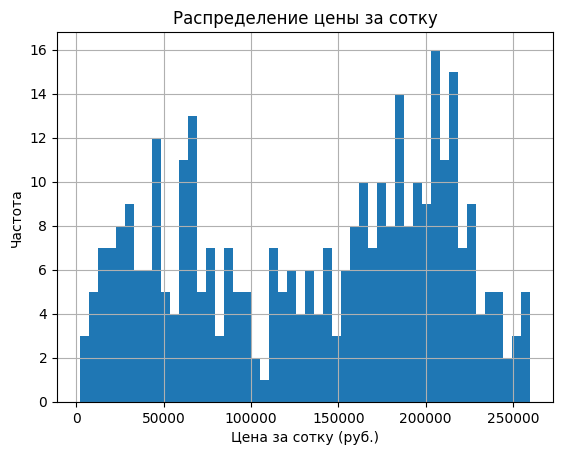

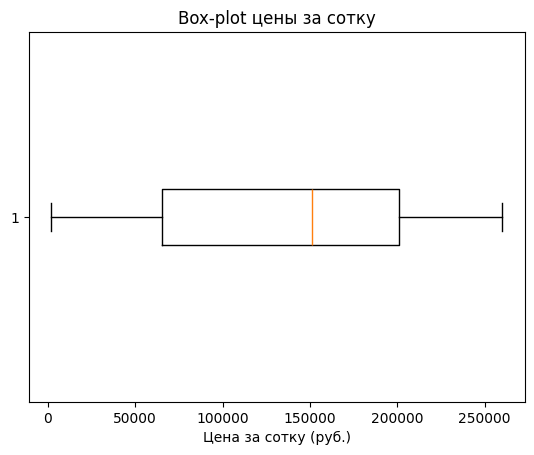

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Цена за сотку (100 м²)
blocks_pred["price_per_sotka"] = blocks_pred["land_value"] / blocks_pred["site_area"] * 100

# 2) Заменяем inf на NaN
blocks_pred["price_per_sotka"] = blocks_pred["price_per_sotka"].replace([np.inf, -np.inf], np.nan)

# 3) Удаляем выбросы: оставляем данные до 99-го перцентиля
p99 = blocks_pred["price_per_sotka"].quantile(0.99)
blocks_clean = blocks_pred[blocks_pred["price_per_sotka"] <= p99].copy()

print(blocks_clean["price_per_sotka"].describe())

# 4) Гистограмма после очистки
plt.figure()
blocks_clean["price_per_sotka"].dropna().hist(bins=50)
plt.xlabel("Цена за сотку (руб.)")
plt.ylabel("Частота")
plt.title("Распределение цены за сотку")
plt.show()

# 5) Box-plot после очистки
plt.figure()
plt.boxplot(blocks_clean["price_per_sotka"].dropna(), vert=False)
plt.xlabel("Цена за сотку (руб.)")
plt.title("Box-plot цены за сотку")
plt.show()


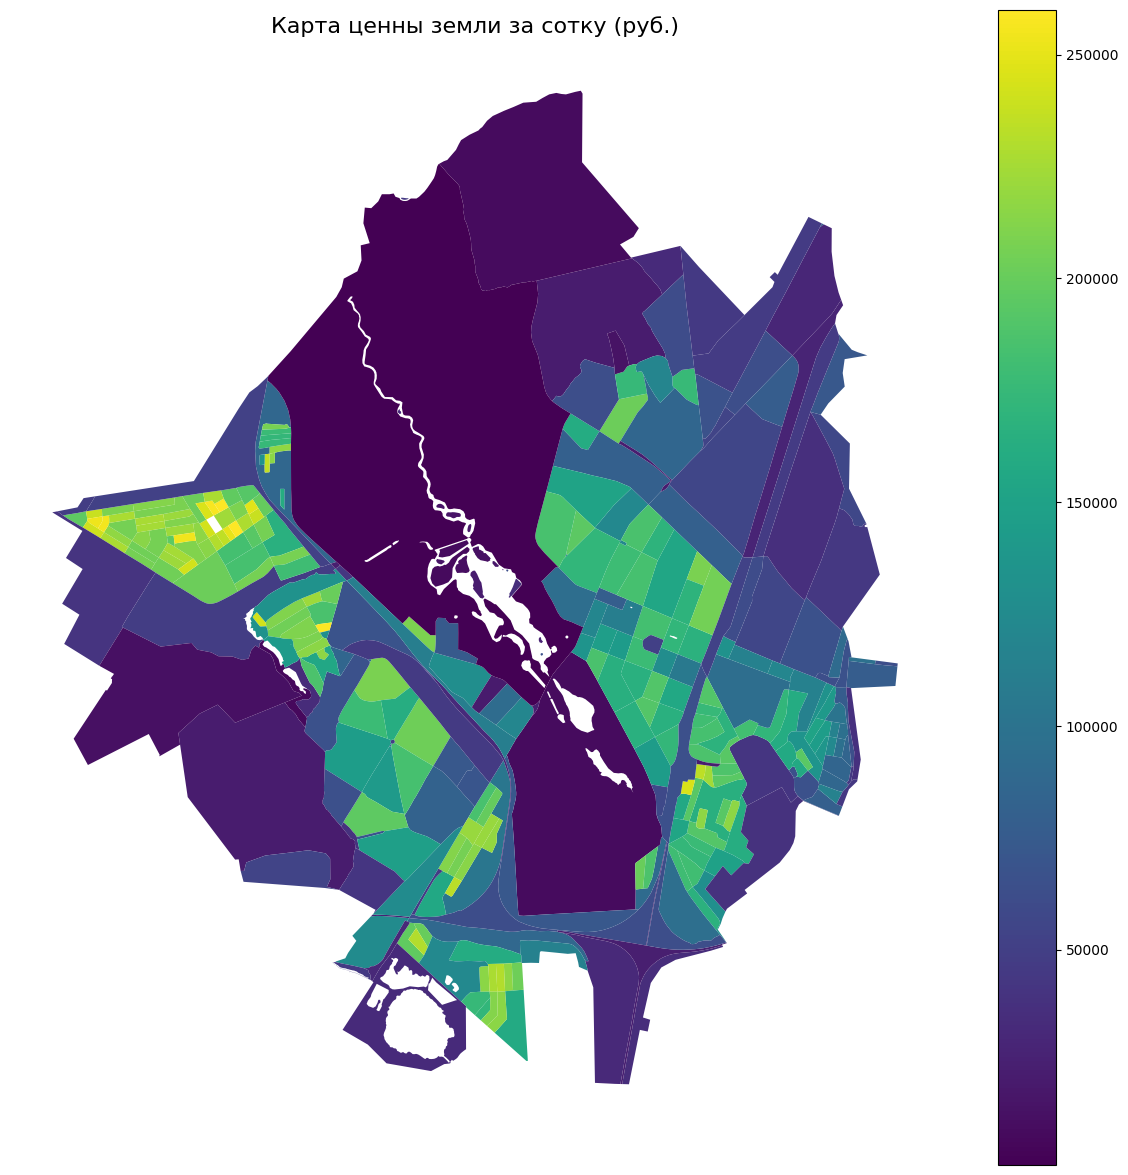

In [46]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='price_per_sotka',
    legend=True,
    figsize=(15,15),
    cmap='viridis'
).set_axis_off()
plt.title('Карта ценны земли за сотку (руб.)', fontsize=16)

plt.show()

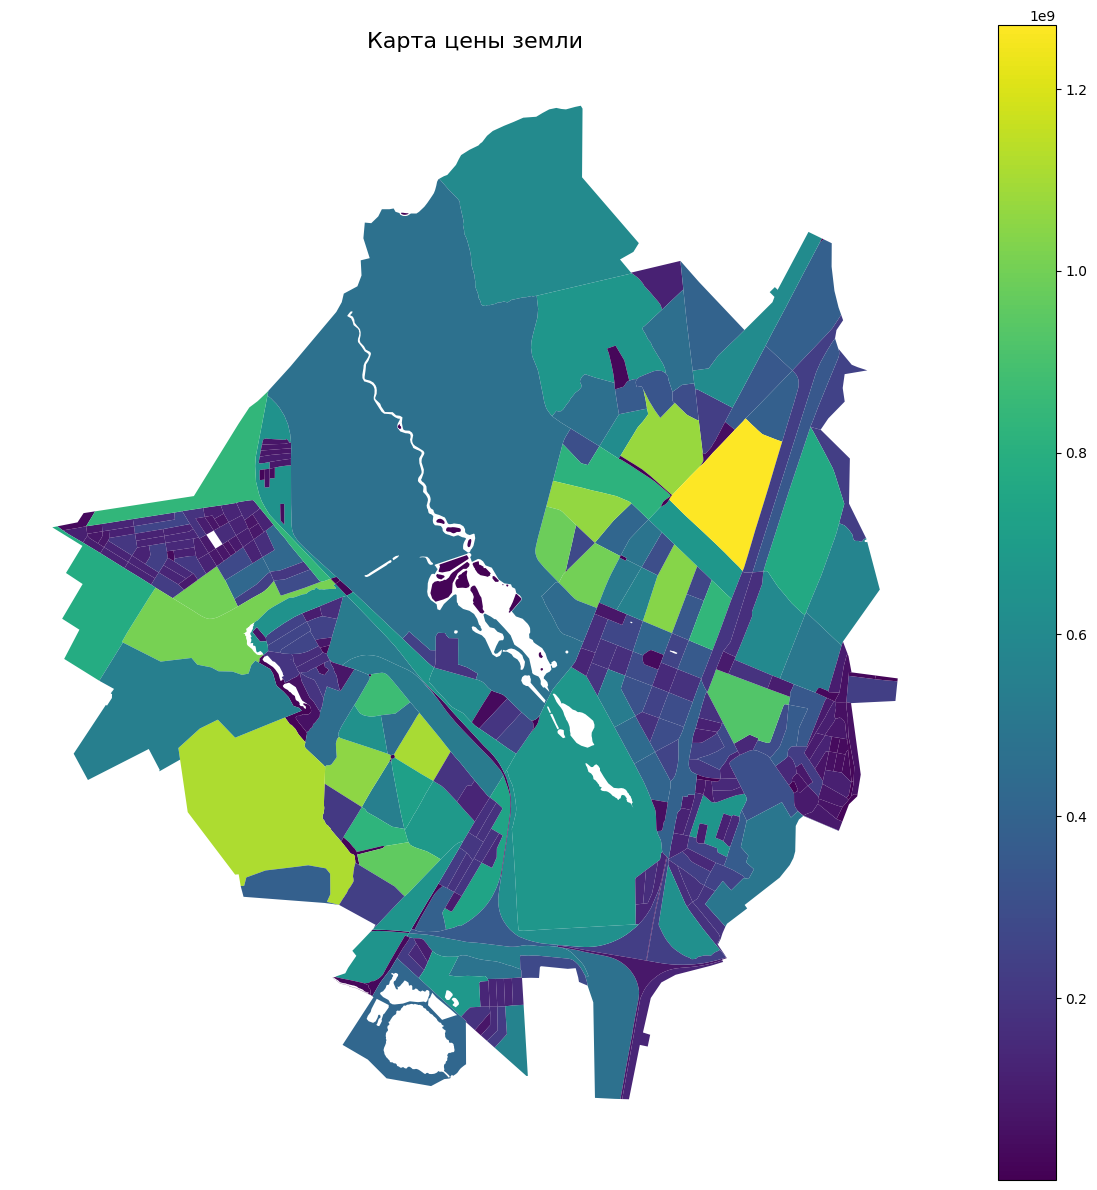

In [47]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value',
    legend=True,
    figsize=(15,15),
    cmap='viridis'
).set_axis_off()
plt.title('Карта цены земли', fontsize=16)

plt.show()

In [58]:
blocks_clean["id"] = blocks_clean.index

In [59]:
blocks_clean.explore()

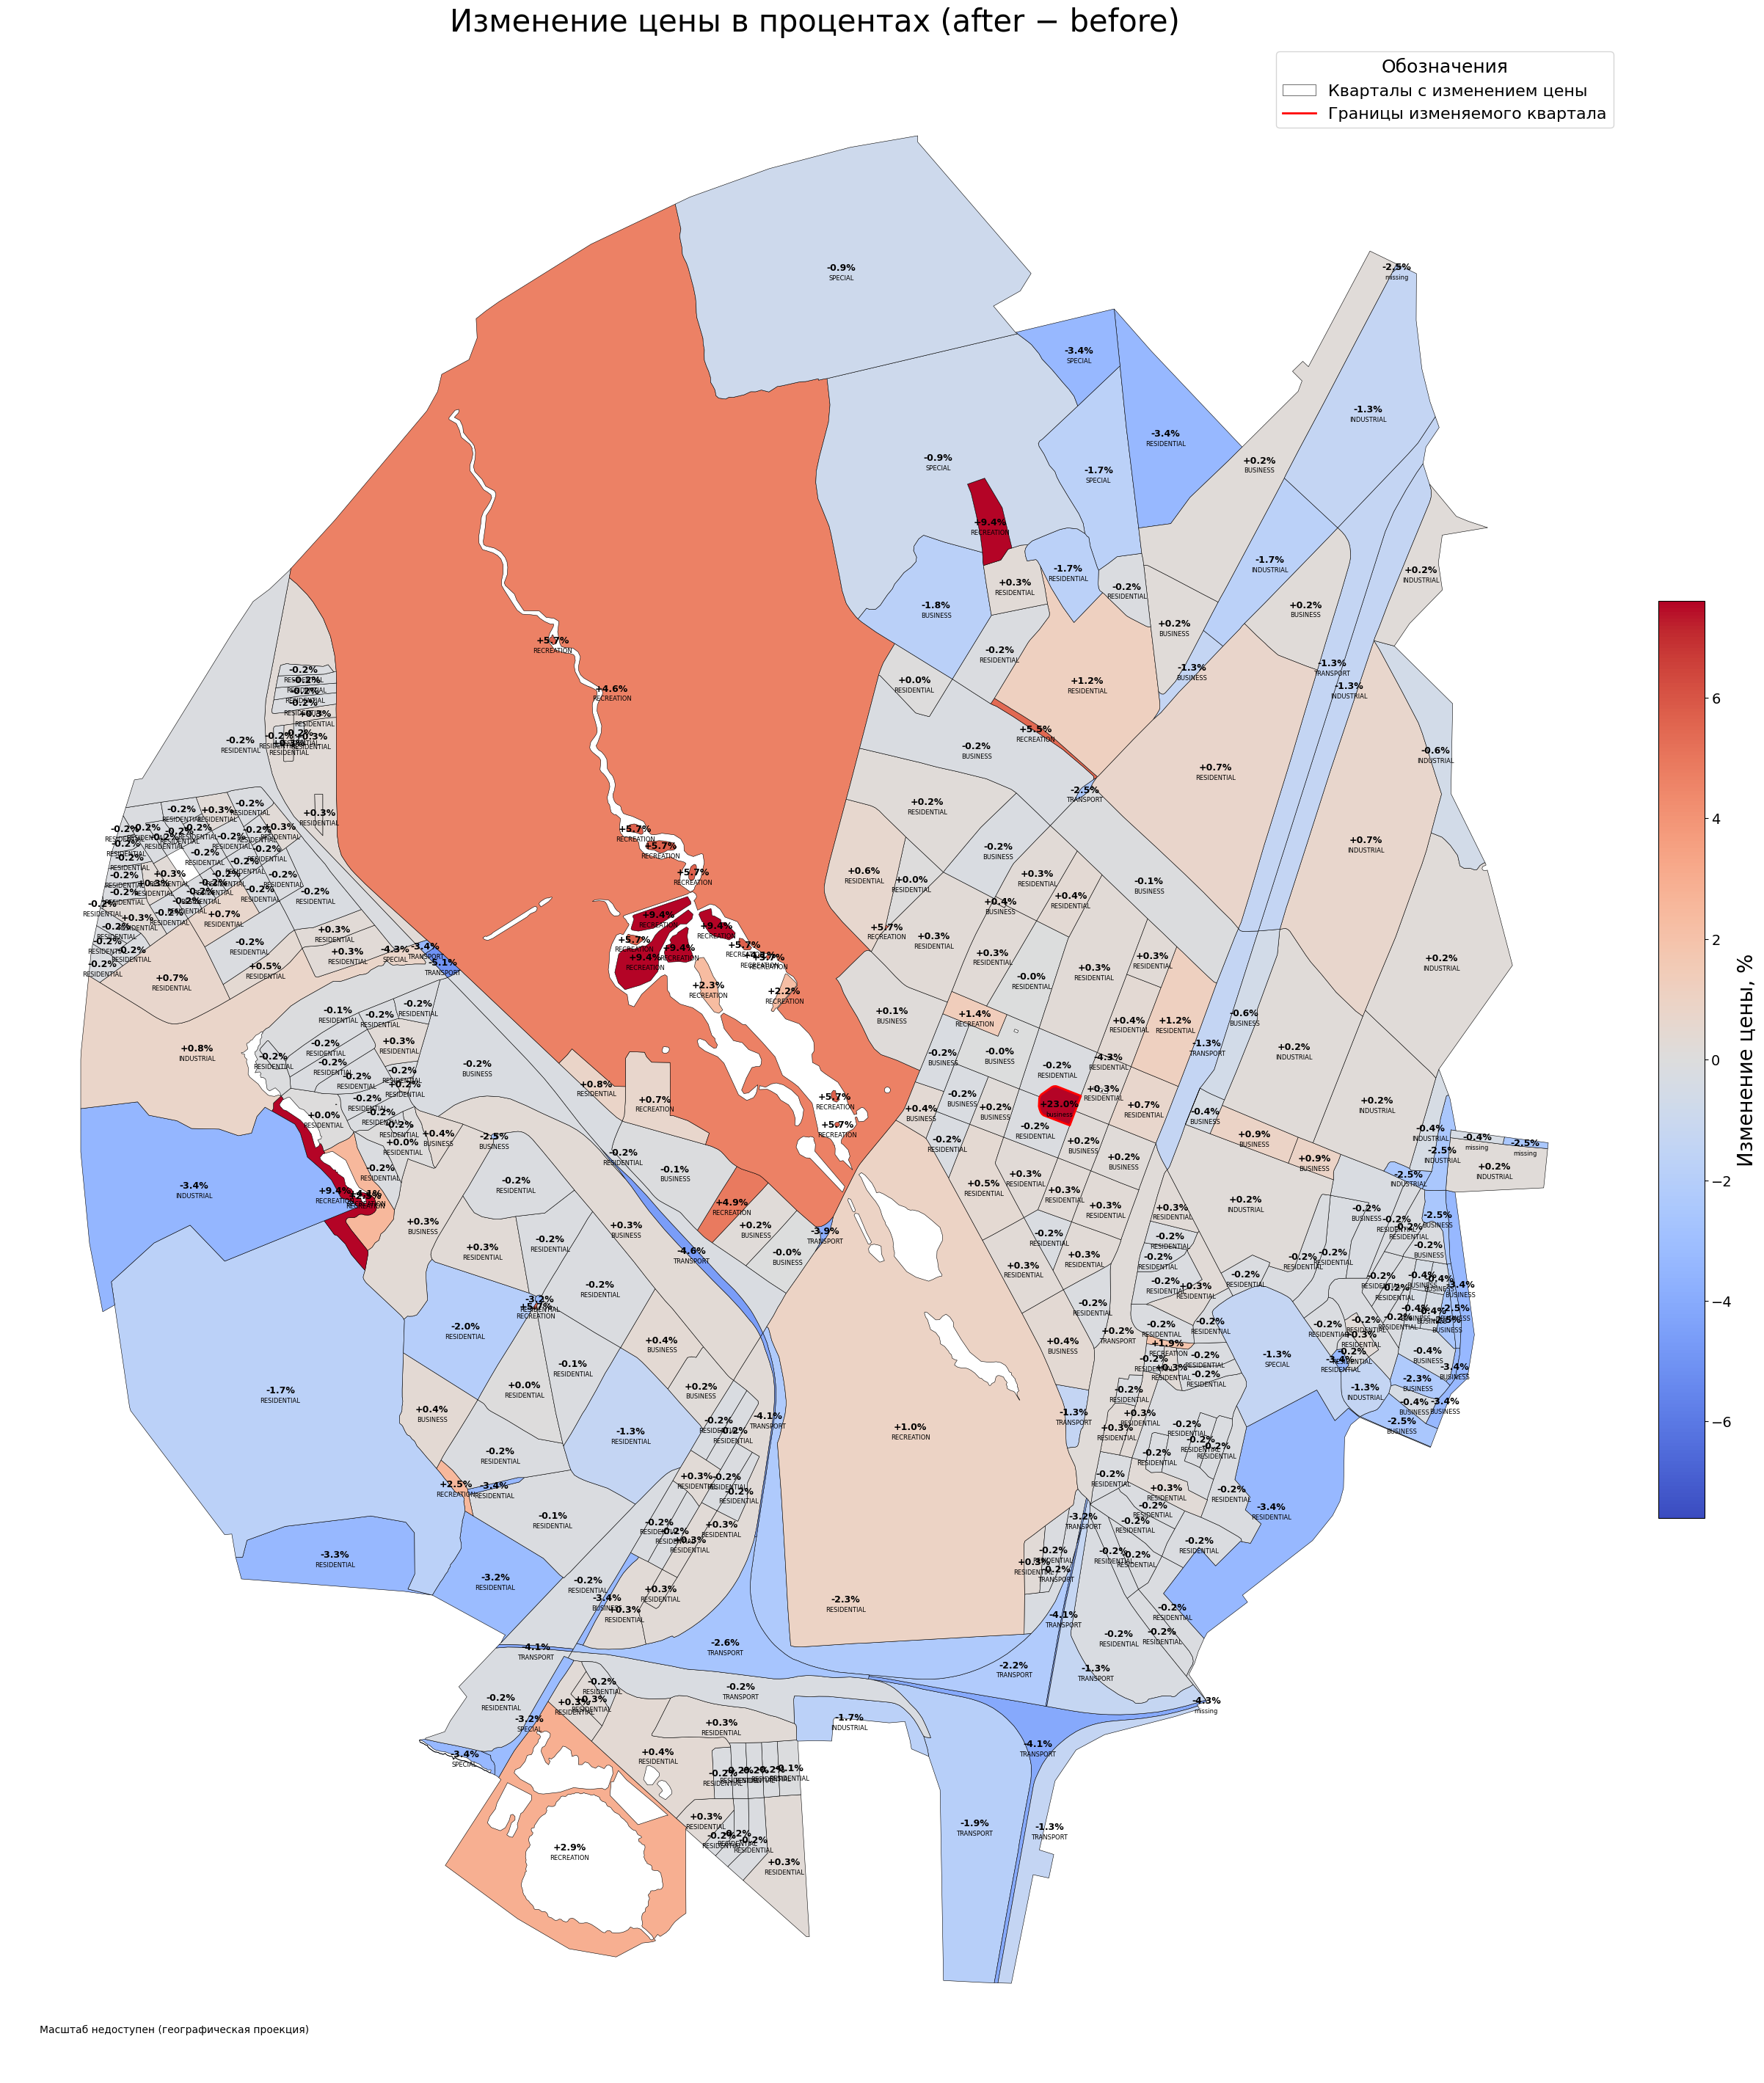


Статистика по кварталам в пределах буфера (|Δ₽| > 1e-09):
index | до (₽) → после (₽) | Δ₽ | Δ%
311 | 558 068 634 ₽ → 559 646 757 ₽ | +1 578 124 ₽ | +0.3%
248 | 463 610 653 ₽ → 454 699 128 ₽ | -8 911 524 ₽ | -1.9%
298 | 90 038 010 ₽ → 86 379 197 ₽ | -3 658 813 ₽ | -4.1%
115 | 129 175 469 ₽ → 128 972 346 ₽ | -203 123 ₽ | -0.2%
317 | 157 610 237 ₽ → 157 488 614 ₽ | -121 623 ₽ | -0.1%
318 | 283 475 839 ₽ → 278 570 408 ₽ | -4 905 431 ₽ | -1.7%
225 | 237 712 832 ₽ → 232 480 853 ₽ | -5 231 979 ₽ | -2.2%
299 | 3 887 664 ₽ → 3 729 684 ₽ | -157 980 ₽ | -4.1%
5 | 134 459 896 ₽ → 134 193 982 ₽ | -265 914 ₽ | -0.2%
113 | 146 458 804 ₽ → 146 872 965 ₽ | +414 161 ₽ | +0.3%
226 | 137 350 848 ₽ → 135 537 506 ₽ | -1 813 341 ₽ | -1.3%
180 | 13 327 ₽ → 12 759 ₽ | -568 ₽ | -4.3%
117 | 176 013 387 ₽ → 175 736 613 ₽ | -276 774 ₽ | -0.2%
268 | 187 262 579 ₽ → 186 968 116 ₽ | -294 463 ₽ | -0.2%
181 | 633 042 760 ₽ → 631 790 826 ₽ | -1 251 934 ₽ | -0.2%
341 | 233 997 132 ₽ → 231 055 108 ₽ | -2 942 024 ₽ | -1.3

In [87]:
from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    plot_scenario_impact,
)

blocks_before = blocks_clean
changes = {
    # Функциональное назначение
    'land_use': 'LandUse.BUSINESS',
    'residential': 0.0,
    'business': 1.0,
    'recreation': 0.0,
    'industrial': 0.0,
    'transport': 0.0,
    'special': 0.0,
    'agriculture': 0.0,
    'share': 1.0,  # участок почти полностью под рекреацию

    # Морфология и площади (при site_area ~303 188 м²)
    'footprint_area': 601,      # небольшие павильоны, спорт-объекты
    'build_floor_area': 601,    # низкая плотность застройки
    'living_area': 0.0,           # жилья нет
    'non_living_area': 601.0,   # вся площадь – нежилая (кафе, спорт, админ.)

    # Население
    'population': 0,              # постоянных жителей нет

    # Морфотип
    'morphotype': 'low-rise non-residential',
}
target_idx = 174

modifier = ScenarioTEPModifier(blocks_before)
blocks_after = modifier.apply(target_idx, changes)

scenario_result = plot_scenario_impact(
    blocks_before=blocks_before,
    blocks_after=blocks_after,
    model=model,
    target_idx=target_idx,
    figsize=(25, 40),
)

In [82]:
from blocksnet.enums import LandUse

benchmarks_demo = {
    LandUse.RESIDENTIAL: {
        "cost_build": 45_000,
        "price_sale": 120_000,
        "construction_years": 3,
        "sale_years": 3,
        "opex_rate": 800,
    },
    LandUse.BUSINESS: {
        "cost_build": 55_000,
        "rent_annual": 25_000,
        "rent_years": 12,
        "construction_years": 4,
        "opex_rate": 1_300,
    },
    LandUse.RECREATION: {
        "cost_build": 20_000,
        "rent_annual": 4_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_000,
    },
    LandUse.SPECIAL: {
        "cost_build": 35_000,
        "rent_annual": 11_000,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_500,
    },
    LandUse.INDUSTRIAL: {
        "cost_build": 38_000,
        "rent_annual": 14_800,
        "rent_years": 12,
        "construction_years": 3,
        "opex_rate": 700,
    },
    LandUse.AGRICULTURE: {
        "cost_build": 25_000,
        "rent_annual": 6_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 300,
    },
    LandUse.TRANSPORT: {
        "cost_build": 18_000,
        "rent_annual": 6_200,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 600,
    },
}

In [84]:
blocks_clean

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,mxi,l,morphotype,area_accessibility,geometry,land_value,price_per_sqm,price_per_sotka,id,land_value_before
0,0.690207,0.211718,0.055976,0.000000,0.042093,0.000000,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,0.091908,1.371459,individual residential,8.523715,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",6.833466e+08,817.128683,81712.868330,0,6.833466e+08
1,0.970519,0.029484,0.000000,0.000000,0.000000,0.000000,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,0.712492,5.824002,mid-rise,8.697457,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",8.727378e+08,2077.234846,207723.484640,1,8.727378e+08
2,0.936589,0.010562,0.052849,0.000000,0.000000,0.000000,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,0.786029,5.365401,mid-rise,7.796253,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",6.121753e+08,2020.476874,202047.687390,2,6.121753e+08
3,0.121353,0.819171,0.059489,0.000000,0.000000,0.000000,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,0.198114,2.288643,low-rise model,6.107342,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",1.809802e+08,1453.108137,145310.813724,3,1.809802e+08
4,0.068737,0.931312,0.000000,0.000000,0.000000,0.000000,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,0.095598,2.187029,low-rise model,6.742033,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",1.709968e+08,1430.038452,143003.845248,4,1.709968e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346,0.085212,0.005620,0.000000,0.042102,0.000000,0.877347,0.0,LandUse.SPECIAL,0.877347,2246.815967,...,0.197735,1.381096,individual residential,NaN,"POLYGON ((30.13472 59.59243, 30.13519 59.59012...",4.589715e+08,610.508730,61050.872974,346,4.589715e+08
347,0.603114,0.000000,0.000000,0.000000,0.000000,0.392772,0.0,LandUse.RESIDENTIAL,0.603114,0.000000,...,0.000000,0.000000,NaN,NaN,"POLYGON ((30.13429 59.59456, 30.13472 59.59243...",3.994135e+08,448.394213,44839.421337,347,3.994135e+08
348,0.921247,0.007951,0.070064,0.000000,0.000000,0.000000,0.0,LandUse.RESIDENTIAL,0.921247,0.000000,...,0.000000,0.000000,NaN,11.629400,"POLYGON ((30.06949 59.54791, 30.06991 59.54711...",3.841310e+08,539.895049,53989.504887,348,3.841310e+08
349,0.604336,0.000000,0.393593,0.000000,0.000000,0.000000,0.0,LandUse.RESIDENTIAL,0.604336,0.000000,...,0.000000,0.000000,NaN,7.745457,"POLYGON ((30.084 59.5465, 30.08427 59.54673, 3...",2.374099e+08,417.770869,41777.086873,349,2.374099e+08


In [83]:
from urbanomy.methods.investment_potential import InvestmentAttractivenessAnalyzer

an = InvestmentAttractivenessAnalyzer(benchmarks=benchmarks_demo)
summary = an.calculate_investment_metrics(blocks_clean, discount_rate=0.18)
summary

2025-11-25 16:59:28.058 | WARNING  | urbanomy.utils.investment_input:prepare_investment_input:444 - prepare_investment_input: колонка 'land_value_before' не найдена; значения скопированы из 'land_value'.
2025-11-25 16:59:28.064 | WARNING  | urbanomy.methods.investment_potential.investment_metrics:calculate_investment_metrics:556 - calculate_investment_metrics: 5 из 345 кварталов без land-use; пропускаем их в расчётах, но оставляем в итоговом отчёте.


KeyError: "Unknown land-use 'LandUse.RESIDENTIAL'"